In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import rbf_kernel
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader, TensorDataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

n=10000

x_train = torch.cat((mnist_train.data.float(), mnist_test.data.float()),0).to(torch.float32)[:n,]
y_train = torch.cat((mnist_train.targets, mnist_test.targets),0).to(torch.float32)[:n,]

del mnist_train
del mnist_test

x_train = x_train.view(x_train.shape[0], -1)/255

import torch.nn.functional as F

x_train = F.normalize(x_train, p=2, dim=1)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x_train shape: torch.Size([10000, 784])
y_train shape: torch.Size([10000])


In [3]:
torch.norm(x_train, p=2, dim=1)

tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000])

In [4]:
x_new = x_train.T
print(x_new.shape)

#--------------------------------------------------------------
# Initialize a list to hold the data for each label
label_lists = [[] for _ in range(10)]

# Separate the data by label
for i in range(x_train.shape[0]):
    label = int(y_train[i])
    label_lists[label].append(x_train[i])

# Ensure all elements in each list have the same shape
for i in range(10):
    label_lists[i] = np.stack(label_lists[i], axis=0) 
    
# Convert the lists to numpy arrays and then to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X = [torch.tensor(np.array(label_list), dtype=torch.float32, device=device) for label_list in label_lists]
#---------------------------------------------------------------
x_mnist_new = torch.cat(X).t()
y_mnist_new = []

for label, tensor in enumerate(X):
    y_mnist_new.extend([label] * tensor.shape[0])

y_train = np.array(y_mnist_new)
#--------------------------------------------------------------
for i in range(10):
  X[i] = X[i].t()

for i in X:
  print(i.shape)

print('--------------------')
print(x_mnist_new.shape)
del x_mnist_new
print(y_train.shape)

torch.Size([784, 10000])
torch.Size([784, 1001])
torch.Size([784, 1127])
torch.Size([784, 991])
torch.Size([784, 1032])
torch.Size([784, 980])
torch.Size([784, 863])
torch.Size([784, 1014])
torch.Size([784, 1070])
torch.Size([784, 944])
torch.Size([784, 978])
--------------------
torch.Size([784, 10000])
(10000,)


## Correct

In [5]:
# X, y_train = data_generate('iid')
# X_cat = torch.cat(X, dim=1)

result = []

for i in range(10):

    gamma = 2
    similarity_matrix = rbf_kernel(x_train, gamma = gamma)
    # similarity_matrix = rbf_kernel(X_cat.t().detach().cpu().numpy(), gamma = gamma)
    print('similarity DONE')

    n_clusters = 10
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
    predicted_labels = spectral.fit_predict(similarity_matrix)

    print('DONE')

    nmi = normalized_mutual_info_score(y_train, predicted_labels)
    ari = adjusted_rand_score(y_train, predicted_labels)

    result.append([nmi, ari])

final_mean = np.mean(result, 0)
final_var = np.var(result, 0)**(1/2)

print('mean:')
print(f'NMI: {final_mean[0]}')
print(f'ARI: {final_mean[1]}')

print('std:')
print(f'NMI: {final_var[0]}')
print(f'ARI: {final_var[1]}')

similarity DONE


KeyboardInterrupt: 

## Fed

In [6]:
def gaussian_kernel(x, y, sigma=1000.0):
    beta = 1.0 / (2.0 * sigma ** 2)
    dist = torch.cdist(x.t(), y.t()) ** 2
    # print(dist.mean())
    kernel = torch.exp(-beta * dist)
    return kernel

def mmd_loss(x, y, sigma_list=[5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 50.0]):

    mmd_list = []
    for sigma in sigma_list:
      xx_kernel = gaussian_kernel(x, x, sigma)
      yy_kernel = gaussian_kernel(y, y, sigma)
      xy_kernel = gaussian_kernel(x, y, sigma)
      mmd = xx_kernel.mean() + yy_kernel.mean() - 2 * xy_kernel.mean()
      mmd_list.append(mmd)
    return max(mmd_list)

# 假设我们有 k 个数据集 X1 到 Xk
k = 10
n = 10000//k  # 288
m = 784
ny = 500
batch_size = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def approximate_Y(X, beta = 0.0, num_epochs = 500):
  
  Y = torch.rand((m, ny), dtype=torch.float32, requires_grad=True, device=device)
  # print(Y)
  learning_rate = 1e-1
  # optimizer = torch.optim.SGD([Y], lr=learning_rate)
  optimizer = torch.optim.Adam([Y], lr=learning_rate)
  # optimizer = torch.optim.RMSprop([Y], lr=learning_rate)

  # 训练循环
  for epoch in range(num_epochs):

      total_loss = 0.0
      optimizer.zero_grad()
      total_grad = None

      for i in range(k):
          Xi = X[i]

          # mini_batch
          dataset = TensorDataset(Xi.t())
          data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

          for batch in data_loader:
            Xi_batch = batch[0].t()
            loss = mmd_loss(Xi_batch, Y)
            loss.backward()
            total_loss += loss.item()

            gradients = Y.grad
            std_grad = torch.std(gradients)
            noise = torch.randn_like(gradients) * std_grad * beta
            noisy_gradients = gradients + noise

            if total_grad is None:
              total_grad = noisy_gradients
            else:
              total_grad += noisy_gradients
            break # only use first mini-batch

          Y.grad.zero_()

      avg_grad = total_grad / k
      total_loss = total_loss / k

      with torch.no_grad():
          Y.grad = avg_grad
          Y.data=torch.clamp(Y.data, min=0, max=1)
          optimizer.step()
      if epoch== num_epochs-1:
          print('Epoch finished')
  return Y

cuda


In [7]:
def estimate_x_similarity(shuffled_X_cat, Y):
  '''
  shuffled_X_cat
  Y: learned dist
  '''
  B = rbf_kernel(Y.t().cpu().detach().numpy(), shuffled_X_cat.t().cpu().detach().numpy(), gamma=gamma)
  A = rbf_kernel(Y.t().cpu().detach().numpy(), Y.t().cpu().detach().numpy(), gamma=gamma)
  # 0.001, 0.0001
  # A = A + torch.eye(A.shape[0], device = device)*1e-5
  # B = Y.t() @ X_cat
  # A = Y.t() @ Y
  B = torch.tensor(B).to(Y.device)
  A = torch.tensor(A).to(Y.device)

  res = B.t() @ torch.linalg.inv(A) @ B

  # reg = 0.1
  # I = torch.eye(A.shape[0]).to(Y.device)
  # res = B.t() @ torch.linalg.inv(A + reg * I) @ B

  res[torch.arange(res.size(0)), torch.arange(res.size(1))] = 1
  # similarity_matrix = np.clip(similarity_matrix, a_min=0, a_max=None)
  return res

## Fedsc

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Verify the result
for i, tensor in enumerate(X):
    print(f"Tensor {i}: shape = {tensor.shape}, device = {tensor.device}")

X_cat = torch.cat(X, dim=1)
X_cat.shape

Tensor 0: shape = torch.Size([784, 1001]), device = cuda:0
Tensor 1: shape = torch.Size([784, 1127]), device = cuda:0
Tensor 2: shape = torch.Size([784, 991]), device = cuda:0
Tensor 3: shape = torch.Size([784, 1032]), device = cuda:0
Tensor 4: shape = torch.Size([784, 980]), device = cuda:0
Tensor 5: shape = torch.Size([784, 863]), device = cuda:0
Tensor 6: shape = torch.Size([784, 1014]), device = cuda:0
Tensor 7: shape = torch.Size([784, 1070]), device = cuda:0
Tensor 8: shape = torch.Size([784, 944]), device = cuda:0
Tensor 9: shape = torch.Size([784, 978]), device = cuda:0


torch.Size([784, 10000])

In [ ]:
Y = approximate_Y(X, beta = 0.0, num_epochs=1000)

for i in range(24):
    vector = Y[:, torch.randint(0,ny,(1,1))].cpu().detach().numpy()
    image = vector.reshape(28, 28)
    plt.subplot(3, 8, i+1)
    plt.imshow(image, cmap='gray', vmin=0, vmax=1)
    plt.title('28x28 Image')
plt.show()

In [11]:
result = []
cols = X_cat.size(1)

for i in range(10):

    perm = torch.randperm(cols)
    shuffled_X_cat = X_cat[:, perm]

    Y = approximate_Y(X, beta = 0.0, num_epochs=5000)
    print('Y done.')

    similarity_matrix = estimate_x_similarity(shuffled_X_cat, Y).cpu().detach().numpy()
    similarity_matrix = np.clip(similarity_matrix, a_min=0, a_max=1)

    print('similarity DONE')

    n_clusters = 10
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
    predicted_labels = spectral.fit_predict(similarity_matrix)

    print('DONE')

    nmi = normalized_mutual_info_score(y_train[perm], predicted_labels)
    ari = adjusted_rand_score(y_train[perm], predicted_labels)

    print(f'NMI: {nmi}')
    print(f'ARI: {ari}')

    result.append([nmi, ari])

final_mean = np.mean(result, 0)
final_var = np.var(result, 0)**(1/2)

print('mean:')
print(f'NMI: {final_mean[0]}')
print(f'ARI: {final_mean[1]}')

print('std:')
print(f'NMI: {final_var[0]}')
print(f'ARI: {final_var[1]}')

Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5247300692386633
ARI: 0.3723235775056735
Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5222364606045586
ARI: 0.37000599556816166
Epoch finished
Y done.
similarity DONE


...

DONE
NMI: 0.5257357584420169
ARI: 0.37390501981138385
Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.524225434826729
ARI: 0.3739962780021923
Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5286323033494449
ARI: 0.3772831554224598
mean:
NMI: 0.5235143861131427
ARI: 0.37065544315747384
std:
NMI: 0.005106134179050801
ARI: 0.006711553658304039


## Fedsc+

Epoch finished


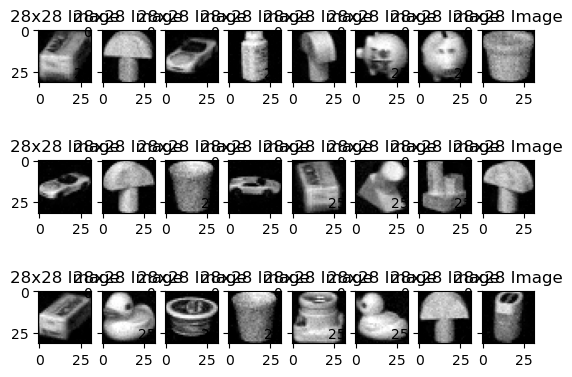

In [ ]:
# Y = approximate_Y(X, beta = 0.1, num_epochs=3000)

# import matplotlib.pyplot as plt
# for i in range(24):
#     vector = Y[:, torch.randint(0,ny,(1,1))].cpu().detach().numpy()
#     image = vector.reshape(32, 32)
#     plt.subplot(3, 8, i+1)
#     plt.imshow(image, cmap='gray', vmin=0, vmax=1)
#     plt.title('28x28 Image')
# plt.show()

In [10]:
result = []
cols = X_cat.size(1)

for i in range(10):

    perm = torch.randperm(cols)
    shuffled_X_cat = X_cat[:, perm]

    Y = approximate_Y(X, beta = 0.1, num_epochs=1000)
    print('Y done.')

    similarity_matrix = estimate_x_similarity(shuffled_X_cat, Y).cpu().detach().numpy()
    similarity_matrix = np.clip(similarity_matrix, a_min=0, a_max=1)

    print('similarity DONE')

    n_clusters = 10
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
    predicted_labels = spectral.fit_predict(similarity_matrix)

    print('DONE')

    nmi = normalized_mutual_info_score(y_train[perm], predicted_labels)
    ari = adjusted_rand_score(y_train[perm], predicted_labels)

    print(f'NMI: {nmi}')
    print(f'ARI: {ari}')

    result.append([nmi, ari])

final_mean = np.mean(result, 0)
final_var = np.var(result, 0)**(1/2)

print('mean:')
print(f'NMI: {final_mean[0]}')
print(f'ARI: {final_mean[1]}')

print('std:')
print(f'NMI: {final_var[0]}')
print(f'ARI: {final_var[1]}')

Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5095996796885753
ARI: 0.38940318919806133
Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5058173510880739
ARI: 0.3909503808586206
Epoch finished
Y done.
similarity DONE


...

DONE
NMI: 0.5039084703600982
ARI: 0.3864646832626267
Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5015373045712949
ARI: 0.37957324778959767
Epoch finished
Y done.
similarity DONE


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:247: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


DONE
NMI: 0.5086342796822271
ARI: 0.3931386547943526
mean:
NMI: 0.5025323521524243
ARI: 0.38292165123542643
std:
NMI: 0.006802880332580854
ARI: 0.01027585632913384
